# Data Analysis & Plots

In [1]:
# Imports & Setup
import sys
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid", font_scale=1.1)

ROOT = Path("..") if Path("../configs").exists() else Path(".")
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from hcm_transcription.preprocessing import TonicNormalizer
from hcm_transcription.segmentation import StaticWindower, AdaptiveWindower, segment_phrases
from hcm_transcription.utils import load_config, load_raga_dict
from hcm_transcription.mapping import MAPPING
from data.loaders.saraga_loader import SaragaHindustaniLoader

cfg = load_config(str(ROOT / "configs" / "default.yaml"))
raga_dict = load_raga_dict(str(ROOT / "data" / "raga_dict.json"))

print(f"Config loaded. Ragas in dict: {len(raga_dict['ragas'])}")
print(f"Ragas in MAPPING: {list(MAPPING.keys())}")

Config loaded. Ragas in dict: 37
Ragas in MAPPING: ['Aahir Bhairon', 'Bairagi', 'Bhairavi Dadra', 'Irani Bhairavi', 'Kalavati', 'Malkauns', 'Chandrakauns', 'Majh Khamaj Thumri', 'Nat Bhairon', 'Raageshree', 'Todi']


In [2]:
# Load Saraga Tracks
loader = SaragaHindustaniLoader(ROOT)

loaded_tracks = {}

for raga_name, entry in MAPPING.items():
    track_id = entry["track_id"]
    if track_id in loaded_tracks:
        continue

    track = loader.load_track(track_id)
    track.raga = raga_name
    track.raga_key = entry["raga_key"]
    
    n_phrases = len(track.phrases) if track.phrases else 0
    duration = track.f0_times[-1] if len(track.f0_times) else 0

    loaded_tracks[track_id] = track

    print(
        f"  Loaded {track_id:30s} | {track.raga:20s} | tonic={track.tonic:.2f} Hz | "
        f"{duration:.0f}s | {len(track.f0_freqs):,} samples"
    )

print(f"\n{len(loaded_tracks)} unique Saraga tracks loaded.")

  Loaded 66_Aahir_Bhairon               | Aahir Bhairon        | tonic=138.59 Hz | 589s | 132,505 samples
  Loaded 59_Bairagi                     | Bairagi              | tonic=138.59 Hz | 899s | 202,201 samples
  Loaded 80_Bhairavi_Dadra              | Bhairavi Dadra       | tonic=155.56 Hz | 602s | 135,350 samples
  Loaded 50_Irani_Bhairavi_Thumri       | Irani Bhairavi       | tonic=196.00 Hz | 360s | 81,071 samples
  Loaded 73_Kalavati                    | Kalavati             | tonic=138.59 Hz | 344s | 77,309 samples
  Loaded 62_Malkauns                    | Malkauns             | tonic=185.00 Hz | 333s | 74,887 samples
  Loaded 54_Raag_Chandrakauns           | Chandrakauns         | tonic=141.01 Hz | 236s | 53,041 samples
  Loaded 55_Majh_Khamaj_Thumri          | Majh Khamaj Thumri   | tonic=141.01 Hz | 319s | 71,790 samples
  Loaded 65_Nat_Bhairon                 | Nat Bhairon          | tonic=138.59 Hz | 638s | 143,502 samples
  Loaded 68_Raageshree                  | Raageshre

### Preprocessing: Tonic Normalization & Quantization

In [3]:

preprocessed = {}

for track_id, trk in loaded_tracks.items():
    raga_key = trk.raga_key
    norm = TonicNormalizer(
        tonic_hz=trk.tonic,
        raga_name=raga_key,
        raga_dict=raga_dict,
        shruti_threshold_cents=cfg["preprocessing"]["shruti_threshold_cents"],
    )
    labels, quant_hz = norm.quantize(trk.f0_freqs)
    preprocessed[track_id] = {
        "labels": labels,
        "quant_hz": quant_hz,
        "norm": norm,
    }

    duration = trk.f0_times[-1] if len(trk.f0_times) else 0
    print(
        f"  Preprocessed {track_id:30s} | {raga_key:20s} | "
        f"{len(labels):,} frames | {duration:.0f}s"
    )

print(f"\nPreprocessed {len(preprocessed)} tracks.")

  Preprocessed 66_Aahir_Bhairon               | ahir_bhairon         | 132,505 frames | 589s
  Preprocessed 59_Bairagi                     | bairagi              | 202,201 frames | 899s
  Preprocessed 80_Bhairavi_Dadra              | bhairavi_dadra       | 135,350 frames | 602s
  Preprocessed 50_Irani_Bhairavi_Thumri       | irani_bhairavi       | 81,071 frames | 360s
  Preprocessed 73_Kalavati                    | kalavati             | 77,309 frames | 344s
  Preprocessed 62_Malkauns                    | malkauns             | 74,887 frames | 333s
  Preprocessed 54_Raag_Chandrakauns           | chandrakauns         | 53,041 frames | 236s
  Preprocessed 55_Majh_Khamaj_Thumri          | majh_khamaj_thumri   | 71,790 frames | 319s
  Preprocessed 65_Nat_Bhairon                 | nat_bhairav          | 143,502 frames | 638s
  Preprocessed 68_Raageshree                  | raageshree           | 110,670 frames | 492s
  Preprocessed 64_Todi                        | todi                 | 121,

## Phrase Segmentation & Instability Computation

In [4]:
static_w = StaticWindower.from_config(cfg)
sample_period = cfg["data"]["f0_sample_period_s"]

print(f"Windower config: frame={static_w.frame_samples} samples, hop={static_w.hop_samples} samples")
print(f"Sample period: {sample_period*1000:.1f} ms")
print(f"Frame duration: {static_w.frame_samples * sample_period * 1000:.1f} ms")
print(f"Hop duration: {static_w.hop_samples * sample_period * 1000:.1f} ms")
print()

track_analysis = {}

for track_id, trk in loaded_tracks.items():
    pp = preprocessed[track_id]
    
    # Segment into phrases
    phrases = segment_phrases(
        f0_hz=trk.f0_freqs,
        times=trk.f0_times,
        quantized_hz=pp["quant_hz"],
        swara_labels=pp["labels"],
        min_silence_duration_s=cfg["segmentation"]["min_silence_duration_ms"] / 1000.0,
        sample_period_s=sample_period,
    )
    
    # Compute instability for each phrase
    phrase_data = []
    for phrase in phrases:
        instab = static_w.compute_instability(phrase.quantized_hz)
        phrase_times = trk.f0_times[phrase.start_idx:phrase.end_idx]
        
        # Identify unstable regions (above threshold)
        if len(instab) > 0:
            threshold = np.nanmean(instab) + np.nanstd(instab)
            unstable_mask = instab > threshold
            unstable_ratio = np.sum(unstable_mask) / len(instab) if len(instab) > 0 else 0
        else:
            threshold = 0
            unstable_ratio = 0
            
        phrase_data.append({
            "phrase": phrase,
            "instab": instab,
            "threshold": threshold,
            "unstable_ratio": unstable_ratio,
        })
    
    track_analysis[track_id] = {
        "phrases": phrases,
        "phrase_data": phrase_data,
    }
    
    total_unstable = np.mean([p["unstable_ratio"] for p in phrase_data]) if phrase_data else 0
    print(f"  {track_id:30s} | {len(phrases):3d} phrases | avg unstable: {total_unstable:.1%}")

print(f"\nAnalyzed {len(track_analysis)} tracks.")

Windower config: frame=56 samples, hop=5 samples
Sample period: 4.4 ms
Frame duration: 248.9 ms
Hop duration: 22.2 ms

  66_Aahir_Bhairon               |  77 phrases | avg unstable: 11.7%
  59_Bairagi                     | 122 phrases | avg unstable: 11.8%
  80_Bhairavi_Dadra              |  57 phrases | avg unstable: 9.6%
  50_Irani_Bhairavi_Thumri       |  49 phrases | avg unstable: 10.8%
  73_Kalavati                    |  52 phrases | avg unstable: 12.2%
  62_Malkauns                    |  48 phrases | avg unstable: 12.4%
  54_Raag_Chandrakauns           |  32 phrases | avg unstable: 10.8%
  55_Majh_Khamaj_Thumri          |  49 phrases | avg unstable: 12.3%
  65_Nat_Bhairon                 |  81 phrases | avg unstable: 11.8%
  68_Raageshree                  |  66 phrases | avg unstable: 12.2%
  64_Todi                        |  75 phrases | avg unstable: 12.8%

Analyzed 11 tracks.


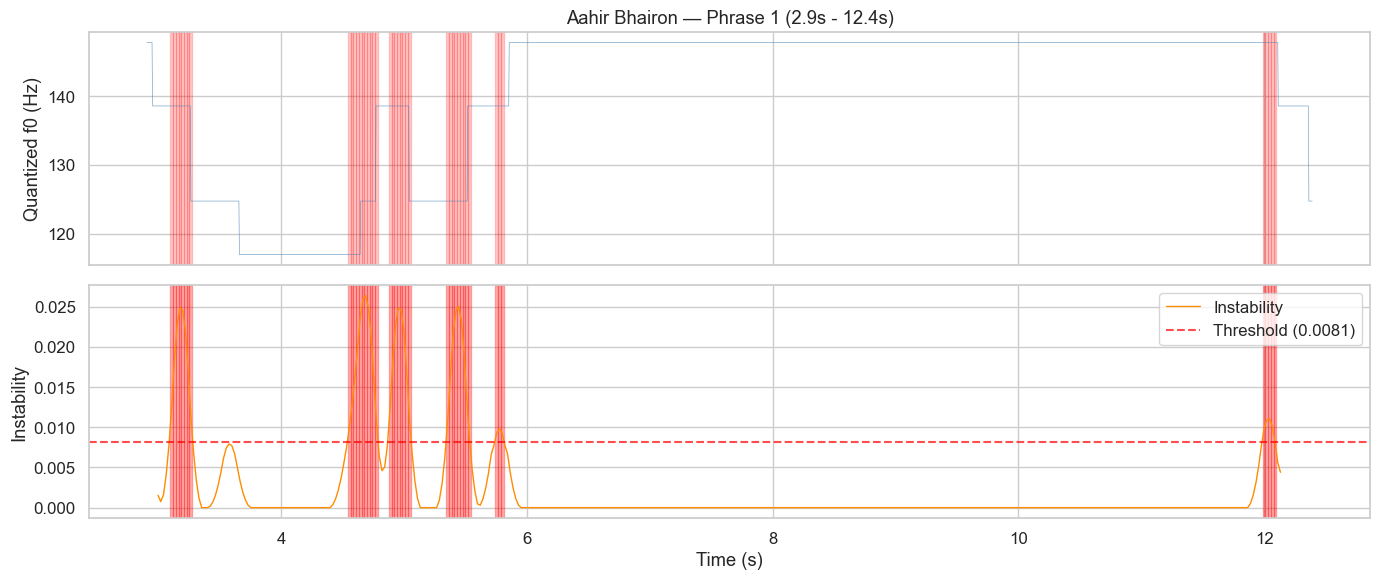

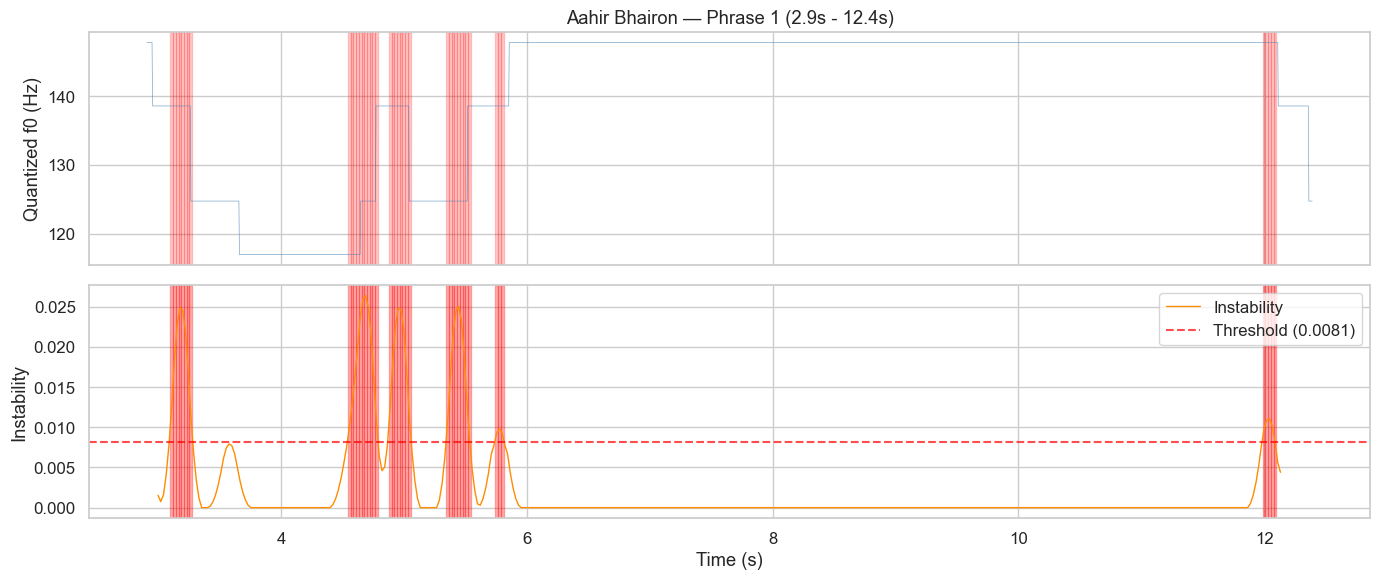

In [5]:
# Visualize Unstable Regions for a Sample Track

def plot_unstable_regions(track_id, phrase_idx=0):
    """Plot f0 contour with instability curve and highlighted unstable regions."""
    trk = loaded_tracks[track_id]
    pp = preprocessed[track_id]
    analysis = track_analysis[track_id]
    
    phrase = analysis["phrases"][phrase_idx]
    pdata = analysis["phrase_data"][phrase_idx]
    instab = pdata["instab"]
    threshold = pdata["threshold"]
    
    # Get phrase slice
    phrase_times = trk.f0_times[phrase.start_idx:phrase.end_idx]
    phrase_quant = pp["quant_hz"][phrase.start_idx:phrase.end_idx]
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    
    # Top: Quantized f0
    axes[0].plot(phrase_times, phrase_quant, lw=0.5, color="steelblue", alpha=0.7)
    axes[0].set_ylabel("Quantized f0 (Hz)")
    axes[0].set_title(f"{trk.raga} — Phrase {phrase_idx+1} ({phrase.start_time:.1f}s - {phrase.end_time:.1f}s)")
    
    # Bottom: Instability curve with threshold
    if len(instab) > 0:
        # Map instability frames to time
        hop_s = static_w.hop_samples
        instab_times = phrase_times[::hop_s][:len(instab)]
        
        axes[1].plot(instab_times, instab, lw=1, color="darkorange", label="Instability")
        axes[1].axhline(threshold, color="red", linestyle="--", alpha=0.7, label=f"Threshold ({threshold:.4f})")
        
        # Highlight unstable regions
        unstable_mask = instab > threshold
        for i, is_unstable in enumerate(unstable_mask):
            if is_unstable and i < len(instab_times):
                axes[1].axvspan(
                    instab_times[i] - hop_s * sample_period / 2,
                    instab_times[i] + hop_s * sample_period / 2,
                    alpha=0.3, color="red"
                )
                # Also highlight on top plot
                axes[0].axvspan(
                    instab_times[i] - hop_s * sample_period / 2,
                    instab_times[i] + hop_s * sample_period / 2,
                    alpha=0.2, color="red"
                )
        
        axes[1].legend(loc="upper right")
    
    axes[1].set_ylabel("Instability")
    axes[1].set_xlabel("Time (s)")
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Plot first phrase of first track
sample_track = list(loaded_tracks.keys())[0]
plot_unstable_regions(sample_track, phrase_idx=0)

In [6]:
# Aggregate Unstable Region Statistics per Raga

raga_stats = []

for track_id, analysis in track_analysis.items():
    trk = loaded_tracks[track_id]
    
    all_instab = []
    all_unstable_ratios = []
    
    for pdata in analysis["phrase_data"]:
        if len(pdata["instab"]) > 0:
            all_instab.extend(pdata["instab"][~np.isnan(pdata["instab"])])
            all_unstable_ratios.append(pdata["unstable_ratio"])
    
    if all_instab:
        raga_stats.append({
            "track_id": track_id,
            "raga": trk.raga,
            "n_phrases": len(analysis["phrases"]),
            "mean_instab": np.mean(all_instab),
            "std_instab": np.std(all_instab),
            "max_instab": np.max(all_instab),
            "avg_unstable_ratio": np.mean(all_unstable_ratios),
            "total_frames": len(all_instab),
        })

df_stats = pd.DataFrame(raga_stats)
print("=== Unstable Region Statistics per Raga ===\n")
print(df_stats.to_string(index=False))

=== Unstable Region Statistics per Raga ===

                track_id               raga  n_phrases  mean_instab  std_instab  max_instab  avg_unstable_ratio  total_frames
        66_Aahir_Bhairon      Aahir Bhairon         77     0.003642    0.008335    0.200000            0.120166         19141
              59_Bairagi            Bairagi        122     0.003810    0.010552    0.857143            0.119658         29348
       80_Bhairavi_Dadra     Bhairavi Dadra         57     0.002190    0.007821    0.182080            0.107655         21679
50_Irani_Bhairavi_Thumri     Irani Bhairavi         49     0.003380    0.009137    0.200000            0.115169         11344
             73_Kalavati           Kalavati         52     0.004260    0.009301    0.200000            0.127060         11017
             62_Malkauns           Malkauns         48     0.004006    0.009073    0.138462            0.129454         11079
    54_Raag_Chandrakauns       Chandrakauns         32     0.003456    0.

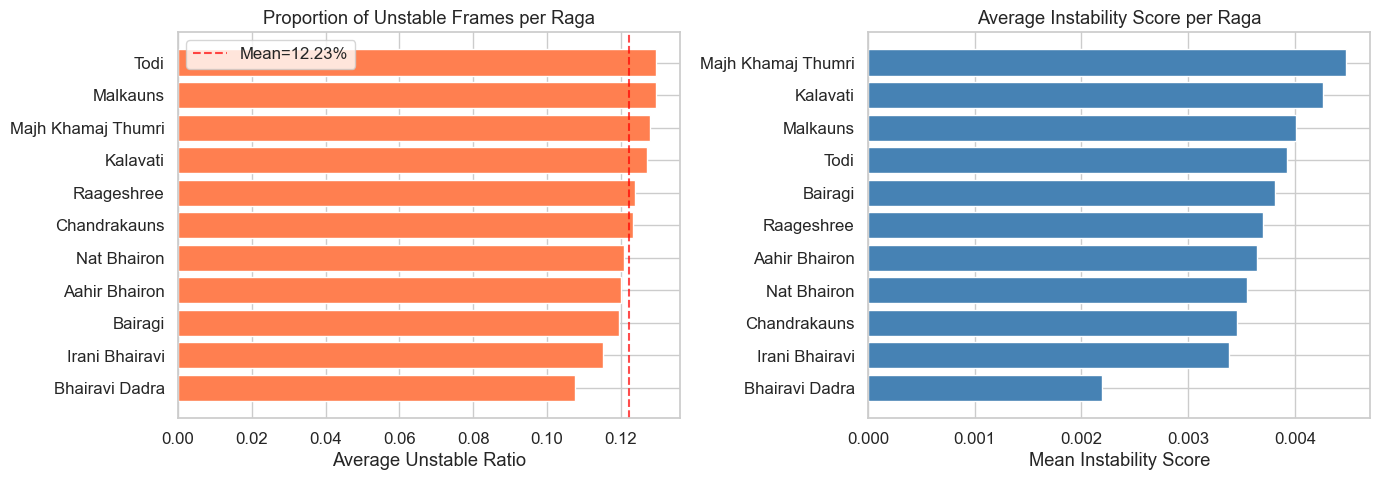

In [7]:
# Compare Unstable Regions Across Ragas

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by avg_unstable_ratio for better visualization
df_sorted = df_stats.sort_values("avg_unstable_ratio", ascending=True)

# Left: Average Unstable Ratio per Raga
axes[0].barh(df_sorted["raga"], df_sorted["avg_unstable_ratio"], color="coral")
axes[0].set_xlabel("Average Unstable Ratio")
axes[0].set_title("Proportion of Unstable Frames per Raga")
axes[0].axvline(df_stats["avg_unstable_ratio"].mean(), color="red", linestyle="--", 
                alpha=0.7, label=f"Mean={df_stats['avg_unstable_ratio'].mean():.2%}")
axes[0].legend()

# Right: Mean Instability Score per Raga
df_sorted2 = df_stats.sort_values("mean_instab", ascending=True)
axes[1].barh(df_sorted2["raga"], df_sorted2["mean_instab"], color="steelblue")
axes[1].set_xlabel("Mean Instability Score")
axes[1].set_title("Average Instability Score per Raga")

plt.tight_layout()
plt.show()

In [8]:
# Extract All Unstable Regions with Timestamps

unstable_regions = []

for track_id, analysis in track_analysis.items():
    trk = loaded_tracks[track_id]
    
    for phrase_idx, pdata in enumerate(analysis["phrase_data"]):
        phrase = analysis["phrases"][phrase_idx]
        instab = pdata["instab"]
        threshold = pdata["threshold"]
        
        if len(instab) == 0:
            continue
            
        # Get phrase times
        phrase_times = trk.f0_times[phrase.start_idx:phrase.end_idx]
        hop_s = static_w.hop_samples
        instab_times = phrase_times[::hop_s][:len(instab)]
        
        # Find contiguous unstable regions
        unstable_mask = instab > threshold
        in_region = False
        region_start = None
        
        for i, (t, is_unstable) in enumerate(zip(instab_times, unstable_mask)):
            if is_unstable and not in_region:
                region_start = t
                in_region = True
            elif not is_unstable and in_region:
                unstable_regions.append({
                    "track_id": track_id,
                    "raga": trk.raga,
                    "phrase_idx": phrase_idx,
                    "region_start": region_start,
                    "region_end": t,
                    "duration": t - region_start,
                    "max_instab": np.max(instab[max(0, i-5):i]),
                })
                in_region = False
        
        # Close final region if still open
        if in_region and len(instab_times) > 0:
            unstable_regions.append({
                "track_id": track_id,
                "raga": trk.raga,
                "phrase_idx": phrase_idx,
                "region_start": region_start,
                "region_end": instab_times[-1],
                "duration": instab_times[-1] - region_start,
                "max_instab": np.max(instab[-5:]) if len(instab) >= 5 else np.max(instab),
            })

df_regions = pd.DataFrame(unstable_regions)
print(f"=== Detected {len(df_regions)} Unstable Regions ===\n")
print(f"Duration stats: min={df_regions['duration'].min():.3f}s, max={df_regions['duration'].max():.3f}s, mean={df_regions['duration'].mean():.3f}s")
print(f"\nRegions per raga:")
print(df_regions.groupby("raga").size().sort_values(ascending=False))

=== Detected 2615 Unstable Regions ===

Duration stats: min=0.000s, max=0.978s, mean=0.167s

Regions per raga:
raga
Bairagi               447
Nat Bhairon           307
Todi                  298
Aahir Bhairon         274
Raageshree            252
Bhairavi Dadra        250
Kalavati              185
Majh Khamaj Thumri    174
Malkauns              164
Irani Bhairavi        152
Chandrakauns          112
dtype: int64


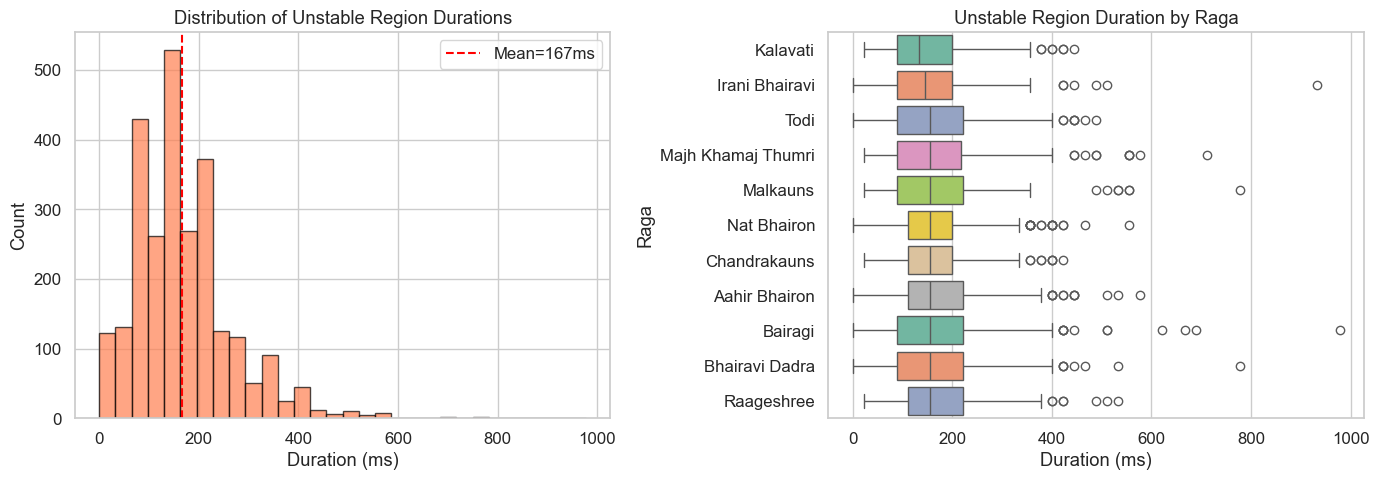


=== Summary ===
Total tracks analyzed: 11
Total phrases segmented: 708
Total unstable regions detected: 2615
Average unstable region duration: 167.2 ms


In [9]:
# Distribution of Unstable Region Durations

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of region durations
axes[0].hist(df_regions["duration"] * 1000, bins=30, color="coral", edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Duration (ms)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Unstable Region Durations")
axes[0].axvline(df_regions["duration"].mean() * 1000, color="red", linestyle="--", 
                label=f"Mean={df_regions['duration'].mean()*1000:.0f}ms")
axes[0].legend()

# Right: Box plot by raga
df_regions_plot = df_regions.copy()
df_regions_plot["duration_ms"] = df_regions_plot["duration"] * 1000
raga_order = df_regions_plot.groupby("raga")["duration_ms"].median().sort_values().index
sns.boxplot(data=df_regions_plot, x="duration_ms", y="raga", order=raga_order, ax=axes[1], palette="Set2")
axes[1].set_xlabel("Duration (ms)")
axes[1].set_ylabel("Raga")
axes[1].set_title("Unstable Region Duration by Raga")

plt.tight_layout()
plt.show()

print("\n=== Summary ===")
print(f"Total tracks analyzed: {len(loaded_tracks)}")
print(f"Total phrases segmented: {sum(len(a['phrases']) for a in track_analysis.values())}")
print(f"Total unstable regions detected: {len(df_regions)}")
print(f"Average unstable region duration: {df_regions['duration'].mean()*1000:.1f} ms")